In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import datetime as dt

In [25]:
stocks = ["PLTR","BABA","DIS","WIX"]
weights = np.array([0.10,0.10,0.10,0.70])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*3)

In [26]:
prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

Media diaria retornos:
Ticker
BABA    0.001081
DIS     0.000227
PLTR    0.004508
WIX     0.000227
dtype: float64
\nMatriz de covarianza:
Ticker      BABA       DIS      PLTR       WIX
Ticker                                        
BABA    0.000718  0.000056  0.000178  0.000173
DIS     0.000056  0.000306  0.000221  0.000133
PLTR    0.000178  0.000221  0.001708  0.000308
WIX     0.000173  0.000133  0.000308  0.000915


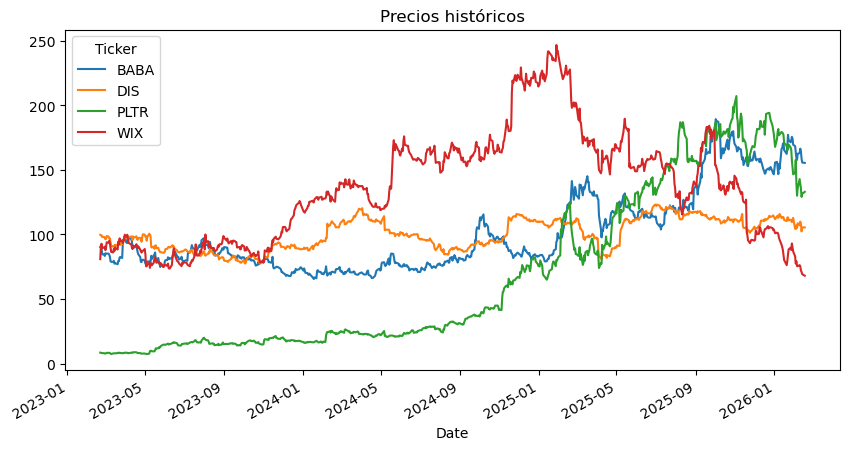

In [27]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

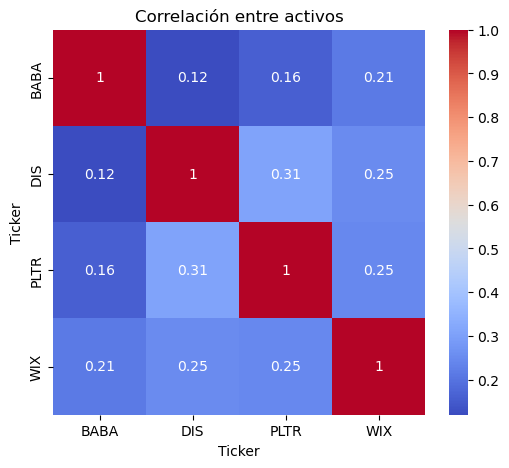

In [28]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

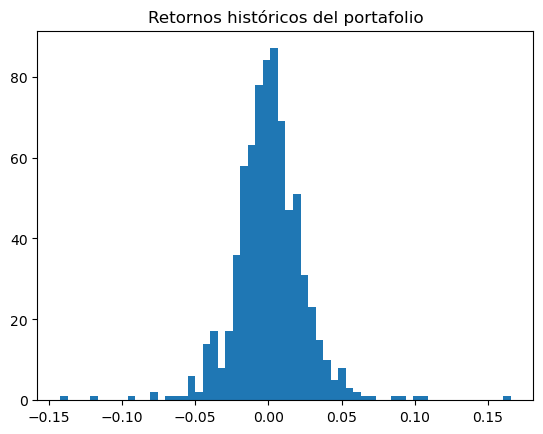

Volatilidad histórica diaria: 0.023886408588640457


In [29]:
portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())

In [30]:
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

In [31]:
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

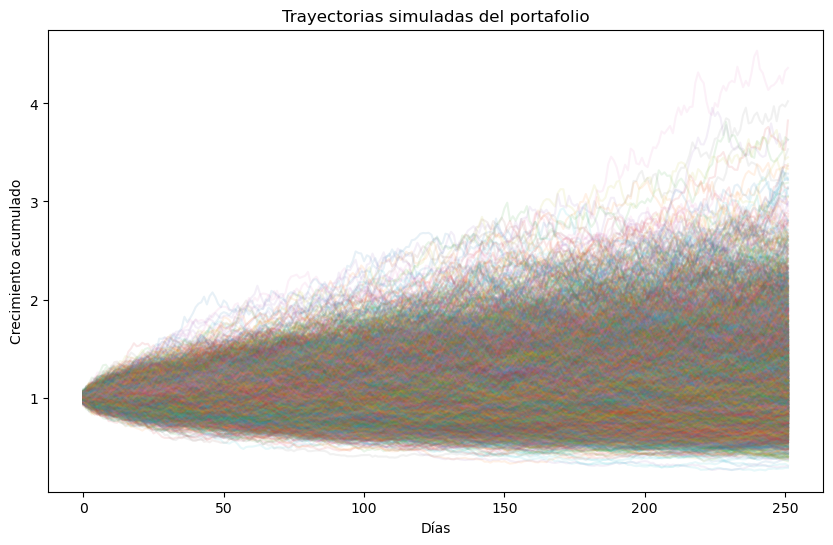

In [32]:
plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

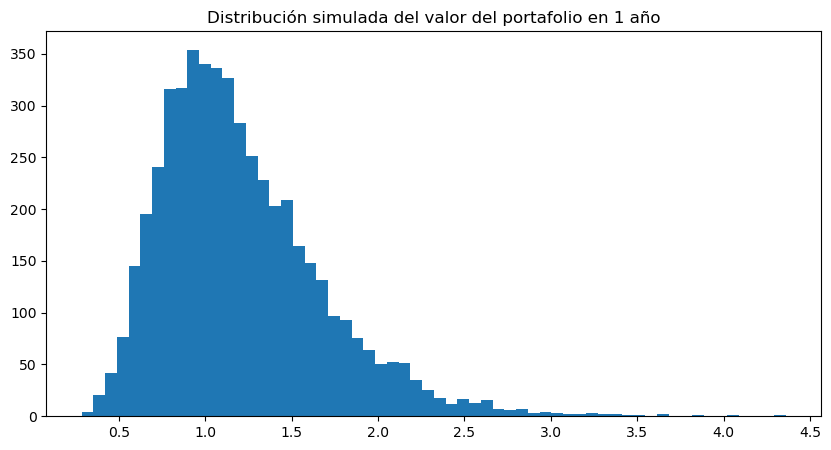

Valor esperado final: 1.2081445812957892
Probabilidad de pérdida: 0.3796


In [33]:
final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))

In [34]:
#Valor promedio final del portafolio
print("Valor promedio final del portafolio:", final_values.mean())
# Valor máximo observado
print("Valor máximo observado:", final_values.max())
# Valor mínimo observado
print("Valor mínimo observado:", final_values.min())

Valor promedio final del portafolio: 1.2081445812957892
Valor máximo observado: 4.361884541422826
Valor mínimo observado: 0.28404929833488407


**Respondido antes de cambiar el código:**

¿Las trayectorias simuladas son similares entre sí o muy distintas? Son similares ya que sus componentes también lo son.

¿La dispersión aumenta con el tiempo? Si.

¿Qué observas en la distribución final del portafolio? Está sesgada hacia los valores más positivos.

**Después de cambiar los tickers y el peso:**

¿Qué observas al modificar el portafolio o el horizonte? También está sesgado y las simulaciones parecen muy similares. Aunque la correlación es muy diferente. Eso sí, entre más tiempo, más dispersión. Como le puse mucho peso a WIX que ha tenido un comportamiento bajista, ahora los rendimientos se fueron más hacia la izquierda (negativas). 
